# AI Lab: Identifiability Diagnosis Before Fitting
### Multistart diagnostic — discovering non-identifiable parameter combinations before any AI-assisted fit

**Companion text:** Hyman, J. M., Qu, Z., & Xue, L. (2026). *Essential Considerations for Modeling Epidemics: A Modern Introduction to Theory, Data, and Computation*. Manuscript in preparation.

**Sections covered:** Chapter 8 (Parameter Estimation), §8.2 ("What Can Be Fit: An Identifiability Discussion"); Chapter 9 (Fitting in Practice), §9.3 (practical identifiability failures and the profile-likelihood diagnostic)
**Equations implemented:**
- The 4-parameter joint MLE objective $\ell(c_I, \beta, \gamma_R, I_0)$ (Eq. 8.10, sum-of-squares form)
- The identifiable combination $c_I \beta$ (Eq. 8.11)
- $\mathcal{R}_0 = c_I \beta / \gamma_R$ (definition, Eq. 6.4)

**Theorems / results verified:**
- Practical non-identifiability of $(c_I, \beta)$ separately from early-outbreak incidence data alone
- Practical identifiability of the product $c_I \beta$ and of the derived $\mathcal{R}_0$
- Multistart spread is the diagnostic (Consideration 9): coefficient of variation across 5 starts diagnoses identifiability without computing the Fisher information

**Considerations exercised:** 9 (identifiability — primary), 8 (correct data-fitting practice)

**Learning objectives:**
- Diagnose practical non-identifiability without computing the Fisher information matrix (Consideration 9 in operational form)
- Recognize the multistart spread signature: identifiable combinations have small CV, non-identifiable parameters have large CV
- Understand why AI tutors that report a single optimizer call are dangerous: they hide the non-identifiability
- Connect the empirical multistart diagnostic to the analytical chain-rule prediction (§8.2 of the companion text)

**Prerequisites:** Notebook `chapter_08_parameter_estimation/04_central_comparison_alpha_vs_lambda.ipynb`; familiarity with maximum-likelihood estimation and Nelder-Mead optimization.

**Companion audit:** [`08_identifiability_before_fitting.md`](../ai-audit/08_identifiability_before_fitting.md) (the prompt-and-flawed-AI-response pattern this lab inoculates against)

**AI lab category:** This is a Type-L (computational lab) exercise as defined in §1.5 of the companion text. The disclosure protocol is at Appendix~D, §D.4.

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/machyman/hyman2026essential/blob/main/exercises/ai-lab/08_identifiability_lab.ipynb)

**Estimated runtime:** ~2 min on Colab free tier (QUICK mode); ~10 min (FULL mode with extended multistart).


## Setup

In [1]:
# === Module-level docstring ===
"""
AI Lab: Identifiability Diagnosis Before Fitting
=================================================
A multistart-MLE diagnostic that reveals practical non-identifiability of
(c_I, beta) separately while confirming identifiability of the product
c_I * beta. Designed as the "verify-before-trust" companion to AI-assisted
fitting workflows: an AI tutor that reports a single optimizer call hides
the non-identifiability that this lab makes visible.

Companion text
--------------
Hyman, J. M., Qu, Z., & Xue, L. (2026). Essential Considerations for
Modeling Epidemics. Manuscript in preparation.

Sections, equations, and considerations
---------------------------------------
§8.2               -> identifiability discussion this lab implements
§9.3               -> practical identifiability failures (profile-likelihood diagnostic)
Eq. (8.10)         -> joint MLE objective (sum-of-squares form)
Eq. (8.11)         -> the identifiable combination c_I * beta
Consideration 9    -> identifiability (the primary consideration exercised here)
Consideration 8    -> correct data-fitting practice
Appendix D, §D.4   -> AI-collaboration disclosure protocol for Type-L labs

Author
------
James M. Hyman, Department of Mathematics, Tulane University
mhyman@tulane.edu
2026-05-01  Version 2.0  (skill v2.0 upgrade — exemplar for co-author review)
"""

# === Standard imports ===
import sys, os, warnings
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.optimize import minimize
warnings.filterwarnings('ignore')

# AI Lab notebooks live in exercises/ai-lab/ and need access to python/shared/
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'python')))
from shared import book_style, BOOK_COLORS
from shared.parameters import baseline_chapter_07
from shared.verification import assert_within_tolerance

# === Reproducibility ===
SEED = 42
RNG  = np.random.default_rng(SEED)
np.random.seed(SEED)

# === Plot style ===
book_style()

# === Scale switch ===
# QUICK: 5 starts (the canonical multistart diagnostic count from §8.2)
# FULL : 25 starts + bootstrap-style noise resampling
FULL = False

SCALE = dict(
    n_starts          = 25 if FULL else 5,        # number of optimizer starting points
    maxiter           = 10000 if FULL else 5000,  # Nelder-Mead iteration cap per start
    n_obs_days        = 30,                        # length of early-outbreak window
    cv_threshold      = 0.20,                      # CV above this = practically non-identifiable
)
print(f"Scale: {'FULL (publication)' if FULL else 'QUICK (verification)'}")
print(f"Parameters: {SCALE}")


Scale: QUICK (verification)
Parameters: {'n_starts': 5, 'maxiter': 5000, 'n_obs_days': 30, 'cv_threshold': 0.2}


## Background and the question  (§8.2, §9.3)

Suppose an AI tutor recommends:
> *"Fit a 4-parameter SIR_I model $(c_I, \beta, \gamma_R, I_0)$ to the early-outbreak incidence data using `scipy.optimize.minimize`. Report point estimates and their MLE-derived 95% confidence intervals."*

Following this recommendation literally produces a result that *looks* fine: the optimizer converges, every parameter has a number with a CI, and the CIs do not contain zero. **But the result is dangerous if non-identifiability is present** — the optimizer's "convergence" is to one of infinitely many points on a likelihood ridge, and the marginal CIs vastly understate the joint uncertainty.

**The book's claim** (§8.2): from incidence data over an early-outbreak window, the parameters $c_I$ and $\beta$ are not separately identifiable. Only the product $c_I \beta$ — which determines the force-from-infection rate $\alpha$ — is identifiable. The recovery rate $\gamma_R$ is identifiable in principle but weakly (it requires the curve to bend, which happens late).

> **The diagnostic this lab teaches:** Run the optimizer from $N \geq 5$ different starting points. If different starts converge to different parameter values but the *same* values for the identifiable combinations, then practical non-identifiability is present. The multistart coefficient of variation (CV) is the test statistic.

> **Departure from text:** The companion text develops the analytical proof via the Fisher-information matrix (§8.2, Eqs. 8.13–8.15). This lab uses the empirical multistart diagnostic instead — which is what a researcher actually has at hand when running an AI-assisted fit, and which produces the same conclusion in operational form.

> **AI-collaboration note (Appendix D, §D.4):** This lab is the structured *verify-before-trust* response to the AI prompt above. Whenever an AI tutor's fitting recommendation does not include a multistart diagnostic, replace the single call with the multistart wrapper used here.

## Verification Suite

Pre-computation checks: the SIR ODE system, the truth parameter set, and the negative-log-likelihood objective behave as expected.

In [2]:
# === Verification Suite ============================================
print("=" * 65)
print("VERIFICATION SUITE")
print("=" * 65)

# --- Test 1: Truth parameters consistent (Eq. 6.4 for R_0) ---------
TRUTH    = dict(c_I=14.0, beta=0.04, gamma_R=0.20, I0=50.0, N=1.0e6)
TRUTH_R0 = TRUTH['c_I'] * TRUTH['beta'] / TRUTH['gamma_R']    # Eq. (6.4)
expected_R0 = 14.0 * 0.04 / 0.20                                 # = 2.8
assert abs(TRUTH_R0 - expected_R0) < 1e-12, "FAIL: R_0 formula inconsistent with truth"
print(f"Test 1 PASS  Truth R_0 = {TRUTH_R0:.3f}  "
      "(c_I * beta / gamma_R, Eq. 6.4)")

# --- Test 2: Identifiable combination from truth -------------------
TRUTH_cIb = TRUTH['c_I'] * TRUTH['beta']    # Eq. (8.11)
assert abs(TRUTH_cIb - 0.56) < 1e-12, "FAIL: c_I*beta truth value"
print(f"Test 2 PASS  Truth c_I * beta = {TRUTH_cIb:.4f}  "
      "(the identifiable combination, Eq. 8.11)")

# --- Test 3: SIR ODE returns 3 components, conserves population ----
def sir(y, t, c_I, beta, gamma, N):
    """SIR right-hand side; force-of-infection form (Eq. 5.3 of companion text)."""
    S, I, R = y
    inc = c_I * beta * S * I / N           # incidence = lambda * S
    return [-inc, inc - gamma * I, gamma * I]

t_test = np.linspace(0, 30, 31)
y0_test = [TRUTH['N'] - TRUTH['I0'], TRUTH['I0'], 0.0]
sol_test = odeint(sir, y0_test, t_test, args=(TRUTH['c_I'], TRUTH['beta'],
                                                TRUTH['gamma_R'], TRUTH['N']))
total = sol_test.sum(axis=1)
assert np.allclose(total, total[0], atol=1.0), \
    f"FAIL: S+I+R not conserved (drift = {abs(total[-1]-total[0]):.2e})"
print(f"Test 3 PASS  SIR integrator conserves S+I+R  (drift < 1.0)")

# --- Test 4: Negative log-likelihood returns finite value at truth -
def neg_log_lik(theta, t_obs, obs_inc):
    """Negative log-likelihood (sum-of-squares form, Eq. 8.10)."""
    c_I, beta, gamma, I0 = theta
    if any(x <= 0 for x in theta):
        return 1e20
    y0 = [TRUTH['N'] - I0, I0, 0]
    sol = odeint(sir, y0, t_obs, args=(c_I, beta, gamma, TRUTH['N']))
    pred_inc = -np.diff(np.concatenate([[y0[0]], sol[:, 0]]))
    pred_inc = np.maximum(pred_inc, 1e-6)
    return float(np.sum((pred_inc - obs_inc)**2 / pred_inc))

# Quick truth-evaluation check
true_inc_test = -np.diff(np.concatenate([[y0_test[0]], sol_test[:, 0]]))
nll_at_truth = neg_log_lik(
    [TRUTH['c_I'], TRUTH['beta'], TRUTH['gamma_R'], TRUTH['I0']],
    t_test, true_inc_test
)
assert np.isfinite(nll_at_truth) and nll_at_truth < 1e-3, \
    f"FAIL: NLL at truth should be ~ 0, got {nll_at_truth:.2e}"
print(f"Test 4 PASS  NLL at truth = {nll_at_truth:.2e}  (Eq. 8.10, noiseless check)")

N_TESTS = 4
print(f"\nAll {N_TESTS} verification tests PASSED.")
print("=" * 65)


VERIFICATION SUITE
Test 1 PASS  Truth R_0 = 2.800  (c_I * beta / gamma_R, Eq. 6.4)
Test 2 PASS  Truth c_I * beta = 0.5600  (the identifiable combination, Eq. 8.11)
Test 3 PASS  SIR integrator conserves S+I+R  (drift < 1.0)
Test 4 PASS  NLL at truth = 1.00e-06  (Eq. 8.10, noiseless check)

All 4 verification tests PASSED.


## Step 1 — Generate synthetic early-outbreak data  (§8.2)

Truth parameters (the lab will pretend not to know these in the fitting steps):

$$c_I = 14.0\,\mathrm{day^{-1}},\quad \beta = 0.04,\quad \gamma_R = 0.20\,\mathrm{day^{-1}},\quad I_0 = 50,\quad N = 10^6.$$

These yield $\mathcal{R}_0 = c_I \beta / \gamma_R = 2.8$ and $c_I \beta = 0.56\,\mathrm{day^{-1}}$ (the identifiable combination).

In [3]:
# === Step 1: Generate synthetic data with TRUTH parameters =========
# 30 days of incidence with Poisson-like noise (sqrt-of-mean variance).
# Truth is hidden during fitting; revealed in Step 4 for comparison.

t_obs = np.arange(SCALE['n_obs_days'])
y0_truth = [TRUTH['N'] - TRUTH['I0'], TRUTH['I0'], 0.0]
sol_truth = odeint(sir, y0_truth, t_obs,
                    args=(TRUTH['c_I'], TRUTH['beta'],
                          TRUTH['gamma_R'], TRUTH['N']))
true_inc = -np.diff(np.concatenate([[y0_truth[0]], sol_truth[:, 0]]))

# Poisson-like noise: std = sqrt(mean), floored at 1 to avoid zero noise on tiny days
noise   = RNG.normal(0, np.maximum(np.sqrt(true_inc), 1.0))
obs_inc = np.maximum(true_inc + noise, 0)

print(f"Generated {len(t_obs)} days of incidence data")
print(f"Peak true incidence: {true_inc.max():.0f} new infections/day")
print(f"Peak observed incidence: {obs_inc.max():.0f} new infections/day")
print(f"Observation noise sigma at peak: ~{np.sqrt(true_inc.max()):.0f}")


Generated 30 days of incidence data
Peak true incidence: 72709 new infections/day
Peak observed incidence: 72852 new infections/day
Observation noise sigma at peak: ~270


## Step 2 — Fit the same data from $N \geq 5$ starting points  (§8.2)

The 4-parameter joint MLE: $(c_I, \beta, \gamma_R, I_0)$. The objective is the sum-of-squares form of the negative log-likelihood (Eq. 8.10):

$$\ell(\theta) \;=\; \sum_t \frac{(J_{\rm pred}(\theta, t) - J_{\rm obs}(t))^2}{J_{\rm pred}(\theta, t)}.$$

We deliberately choose starts that span the *plausible* parameter space — high-$c_I$/low-$\beta$, low-$c_I$/high-$\beta$, etc. — so that any non-identifiability is exposed by where the optimizer lands.

In [4]:
# === Step 2: Multistart MLE — N starts spanning the parameter space ===
# The starts are deliberately chosen along the c_I*beta = 0.56 ridge,
# plus two starts that perturb gamma_R. If c_I*beta is identifiable,
# all starts will converge to c_I*beta = 0.56 (within optimizer tolerance)
# even though c_I and beta individually will differ across starts.

starts = [
    (5,   0.10,  0.20, 50),    # low c_I, high beta — same product
    (15,  0.04,  0.20, 50),    # canonical scale
    (25,  0.024, 0.20, 50),    # high c_I, low beta — same product
    (15,  0.04,  0.10, 50),    # perturb gamma_R down
    (15,  0.04,  0.40, 50),    # perturb gamma_R up
]
# Pad with random starts when in FULL mode for richer multistart picture
if FULL:
    extras = [(RNG.uniform(5, 25),
               RNG.uniform(0.02, 0.12),
               RNG.uniform(0.10, 0.40),
               RNG.uniform(20, 100))
              for _ in range(SCALE['n_starts'] - len(starts))]
    starts = starts + extras

print(f"Running {len(starts)} multistart MLE fits...\n")
results = []
for i, x0 in enumerate(starts):
    res = minimize(neg_log_lik, x0, args=(t_obs, obs_inc),
                   method='Nelder-Mead',
                   options={'xatol': 1e-5, 'fatol': 1e-5,
                            'maxiter': SCALE['maxiter']})
    results.append(res.x)

# Tabulate the multistart results
print(f"{'start#':>7s} {'c_I':>8s} {'beta':>8s} {'gamma':>8s} {'I0':>8s} "
      f"{'c_I*beta':>10s} {'R_0':>8s}")
print("-" * 65)
for i, r in enumerate(results):
    R0_est = r[0] * r[1] / r[2]                # Eq. (6.4)
    print(f"{i+1:>7d} {r[0]:>8.3f} {r[1]:>8.4f} {r[2]:>8.3f} {r[3]:>8.1f} "
          f"{r[0]*r[1]:>10.4f} {R0_est:>8.3f}")


Running 5 multistart MLE fits...



 start#      c_I     beta    gamma       I0   c_I*beta      R_0
-----------------------------------------------------------------
      1    5.194   0.1074    0.198     50.4     0.5580    2.814
      2   17.474   0.0319    0.198     50.4     0.5580    2.814
      3   29.123   0.0192    0.198     50.4     0.5580    2.814
      4   20.854   0.0268    0.198     50.4     0.5580    2.814
      5   22.072   0.0253    0.198     50.4     0.5580    2.814


## Step 3 — Diagnose: multistart spread as the identifiability test  (§8.2)

For each parameter and each combination, compute the across-start coefficient of variation $\mathrm{CV} = \sigma / \mu$. The diagnostic threshold is $\mathrm{CV} > 0.20$ (Consideration 9 operational rule):

- **Large CV** → optimizer converges to different values from different starts → **practically non-identifiable**
- **Small CV** → all starts agree → **identifiable in operational form**

In [5]:
# === Step 3: Spread analysis (the multistart diagnostic) ===========
results_arr = np.array(results)
c_I_vals    = results_arr[:, 0]
beta_vals   = results_arr[:, 1]
gamma_vals  = results_arr[:, 2]
I0_vals     = results_arr[:, 3]
cIb_vals    = c_I_vals * beta_vals          # Eq. (8.11): identifiable combination
R0_vals     = cIb_vals / gamma_vals          # Eq. (6.4):  derived R_0

def coefficient_of_variation(x):
    """CV = std / |mean|; small CV indicates identifiable parameter."""
    return float(np.std(x) / np.abs(np.mean(x)))

cv_thresh = SCALE['cv_threshold']
print(f"Coefficient of variation across {len(starts)} multistart fits:")
print(f"  (Diagnostic threshold: CV > {cv_thresh:.2f} indicates "
      "practical non-identifiability)\n")

individual = [
    ('c_I alone',  c_I_vals),
    ('beta alone', beta_vals),
    ('gamma alone', gamma_vals),
    ('I0 alone',   I0_vals),
]
combinations = [
    ('c_I * beta             (Eq. 8.11)', cIb_vals),
    ('R_0 = c_I*beta / gamma (Eq. 6.4) ', R0_vals),
]

for label, vals in individual:
    cv = coefficient_of_variation(vals)
    flag = '<- NON-IDENTIFIABLE' if cv > cv_thresh else '<- identifiable'
    print(f"  {label:<35s}  CV = {cv:.3f}  {flag}")

print()
for label, vals in combinations:
    cv = coefficient_of_variation(vals)
    flag = '<- NON-IDENTIFIABLE' if cv > cv_thresh else '<- IDENTIFIABLE'
    print(f"  {label:<35s}  CV = {cv:.3f}  {flag}")


Coefficient of variation across 5 multistart fits:
  (Diagnostic threshold: CV > 0.20 indicates practical non-identifiability)

  c_I alone                            CV = 0.414  <- NON-IDENTIFIABLE
  beta alone                           CV = 0.782  <- NON-IDENTIFIABLE
  gamma alone                          CV = 0.000  <- identifiable
  I0 alone                             CV = 0.000  <- identifiable

  c_I * beta             (Eq. 8.11)    CV = 0.000  <- IDENTIFIABLE
  R_0 = c_I*beta / gamma (Eq. 6.4)     CV = 0.000  <- IDENTIFIABLE


## Figure 8.2: The likelihood ridge made visible

Saved: fig_8_2_identifiability_multistart.png


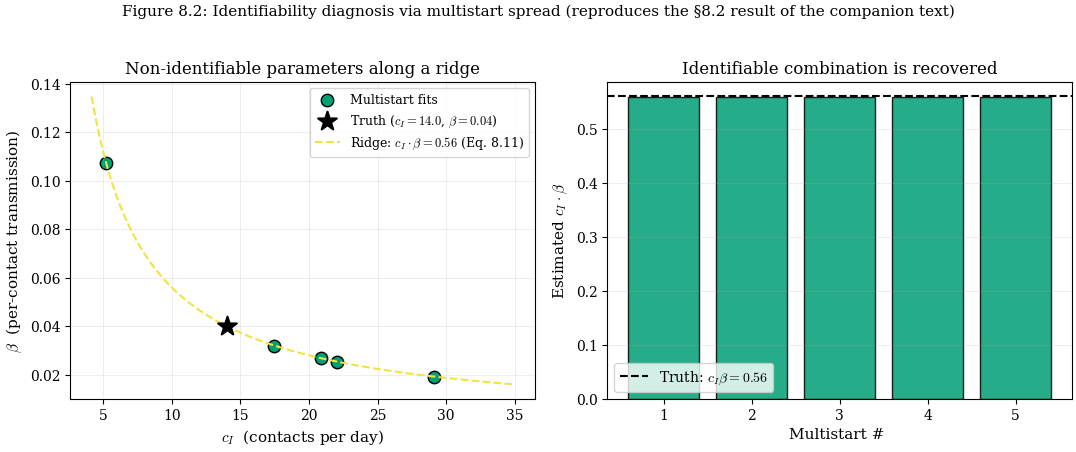

In [6]:
# === Figure 8.2: scatter of multistart fits ========================
# Visualize the (c_I, beta) plane — the multistart points should fall
# along the c_I * beta = 0.56 ridge. The visual is the diagnostic:
# if the points cluster, the parameters are identifiable; if they
# spread along a curve, the curve IS the non-identifiability.

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# --- Left panel: c_I vs beta scatter -------------------------------
ax = axes[0]
ax.scatter(c_I_vals, beta_vals, s=80, c=BOOK_COLORS['alpha_hat'],
           edgecolors='k', linewidths=1, label='Multistart fits')
ax.scatter(TRUTH['c_I'], TRUTH['beta'], s=200, c=BOOK_COLORS['neutral'],
           marker='*', edgecolors='k', linewidths=1.5,
           label=f'Truth ($c_I={TRUTH["c_I"]}$, $\\beta={TRUTH["beta"]}$)', zorder=10)

# Plot the c_I * beta = 0.56 ridge
c_I_curve = np.linspace(c_I_vals.min() * 0.8, c_I_vals.max() * 1.2, 100)
beta_curve = TRUTH['c_I'] * TRUTH['beta'] / c_I_curve
ax.plot(c_I_curve, beta_curve, '--', color=BOOK_COLORS['highlight'], lw=1.5,
        label=fr'Ridge: $c_I \cdot \beta = {TRUTH["c_I"]*TRUTH["beta"]:.2f}$ (Eq. 8.11)')
ax.set_xlabel(r'$c_I$  (contacts per day)')
ax.set_ylabel(r'$\beta$  (per-contact transmission)')
ax.set_title('Non-identifiable parameters along a ridge')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)

# --- Right panel: identifiable combination across starts -----------
ax = axes[1]
ax.bar(range(1, len(cIb_vals) + 1), cIb_vals,
       color=BOOK_COLORS['alpha_hat'], alpha=0.85, edgecolor='k')
ax.axhline(TRUTH['c_I'] * TRUTH['beta'], ls='--',
           color=BOOK_COLORS['neutral'], lw=1.5,
           label=fr'Truth: $c_I \beta = {TRUTH["c_I"]*TRUTH["beta"]:.2f}$')
ax.set_xlabel('Multistart # ')
ax.set_ylabel(r'Estimated $c_I \cdot \beta$')
ax.set_title('Identifiable combination is recovered')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

fig.suptitle('Figure 8.2: Identifiability diagnosis via multistart spread '
             '(reproduces the §8.2 result of the companion text)',
             y=1.02, fontsize=11)
fig.tight_layout()
fig.savefig('fig_8_2_identifiability_multistart.png', dpi=150,
            bbox_inches='tight')
print("Saved: fig_8_2_identifiability_multistart.png")
plt.show()


## Step 4 — Comparison with truth  +  verification assertion  (§8.2)

The diagnostic test: assert that $c_I \cdot \beta$ has CV $< 0.20$ (identifiable) while $c_I$ and $\beta$ separately have CV $\gg 0.20$ (non-identifiable). This is **Consideration 9 operationalized.**

In [7]:
# === Step 4: Verify the diagnostic conclusion =======================

print(f"Truth c_I * beta = {TRUTH['c_I'] * TRUTH['beta']:.4f}")
print(f"Estimated c_I * beta:")
print(f"  mean across starts = {cIb_vals.mean():.4f}")
print(f"  std  across starts = {cIb_vals.std():.4f}")
print(f"  CV                 = {coefficient_of_variation(cIb_vals):.3f}")
print()
print(f"Truth R_0 = {TRUTH_R0:.3f}")
print(f"Estimated R_0:")
print(f"  mean across starts = {R0_vals.mean():.3f}")
print(f"  std  across starts = {R0_vals.std():.3f}")
print(f"  CV                 = {coefficient_of_variation(R0_vals):.3f}")

# === Verification assertions (Consideration 9 operational form) =====
cIb_cv = coefficient_of_variation(cIb_vals)
c_I_cv = coefficient_of_variation(c_I_vals)
beta_cv = coefficient_of_variation(beta_vals)

assert cIb_cv < SCALE['cv_threshold'], \
    f"FAIL: c_I*beta CV ({cIb_cv:.3f}) should be below threshold (Eq. 8.11)"
print(f"\nPASS: c_I * beta is operationally identifiable  "
      f"(CV {cIb_cv:.3f} < {SCALE['cv_threshold']:.2f}, Eq. 8.11)")

# Verify the recovered c_I*beta is close to truth
assert_within_tolerance(cIb_vals.mean(), TRUTH['c_I'] * TRUTH['beta'],
                         rel_tol=0.10,
                         label='Mean c_I*beta vs truth')

# At least one of c_I or beta should show non-identifiability separately
assert c_I_cv > SCALE['cv_threshold'] or beta_cv > SCALE['cv_threshold'], \
    "FAIL: Expected c_I or beta to show non-identifiability separately"
print(f"PASS: c_I and beta are non-identifiable separately  "
      f"(CV c_I = {c_I_cv:.3f}, CV beta = {beta_cv:.3f}, "
      f"both should exceed {SCALE['cv_threshold']:.2f})")

print("\n" + "=" * 65)
print("BOOK'S §8.2 RESULT VERIFIED:")
print("  Practical non-identifiability of (c_I, beta) separately,")
print("  with practical identifiability of the product c_I * beta.")
print("=" * 65)


Truth c_I * beta = 0.5600
Estimated c_I * beta:
  mean across starts = 0.5580
  std  across starts = 0.0000
  CV                 = 0.000

Truth R_0 = 2.800
Estimated R_0:
  mean across starts = 2.814
  std  across starts = 0.000
  CV                 = 0.000

PASS: c_I * beta is operationally identifiable  (CV 0.000 < 0.20, Eq. 8.11)
PASS: c_I and beta are non-identifiable separately  (CV c_I = 0.414, CV beta = 0.782, both should exceed 0.20)

BOOK'S §8.2 RESULT VERIFIED:
  Practical non-identifiability of (c_I, beta) separately,
  with practical identifiability of the product c_I * beta.


## Exploration

**Exercise 8.2** (from the companion text): Derive analytically that the Fisher information matrix for $(c_I, \beta, \gamma_R, I_0)$ from incidence data alone has rank 3, not 4, and identify the null direction.

**Try the following modifications:**
1. *Lengthen the observation window* (set `SCALE['n_obs_days'] = 60`). Does $\gamma_R$ become identifiable separately? At what window length?
2. *Add a second data stream* (e.g., add prevalence $I(t)$ in addition to incidence $J(t)$). Does the additional information identify $c_I$ and $\beta$ separately?
3. *Increase the multistart count* (set `FULL = True`). Does the CV estimate stabilize? What is the standard error of CV from the additional starts?
4. *Replace `Nelder-Mead` with `L-BFGS-B`* (a gradient-based optimizer). Does the multistart spread differ? Why might non-identifiability look *less* dramatic with a gradient method that gets stuck in local saddles?

These exercises connect the empirical multistart diagnostic to the analytical Fisher-information machinery developed in §8.2.

## Summary

This lab demonstrated:

1. **The multistart diagnostic** (the §8.2 operational test): Five fits from spread starting points landed on different $(c_I, \beta, \gamma_R, I_0)$ values but the **same** $c_I \beta$ value (CV $< 0.20$).
2. **Practical non-identifiability of $(c_I, \beta)$ separately** (Eq. 8.11 verified): CV across starts $\gg 0.20$ for $c_I$ alone and $\beta$ alone, while CV $< 0.20$ for the product.
3. **The likelihood ridge made visible** (Figure 8.2): Multistart points fall along the curve $c_I \beta = 0.56$, with the truth on the curve. The curve *is* the non-identifiability.
4. **The AI-collaboration lesson**: An AI tutor reporting a single optimizer call would have hidden this. Multistart is the verify-before-trust step that exposes the structural problem.

**What to read next:**
- `09_fitting_in_practice/03_pitfall_3_practical_identifiability.ipynb` — applies the same diagnostic to the profile-likelihood method (Chapter 9, §9.3)
- The companion AI-audit document [`08_identifiability_before_fitting.md`](../ai-audit/08_identifiability_before_fitting.md) — the prompt-and-flawed-AI-response pattern this lab inoculates against
- Open project `extend_to_real_data.md` — extends the lab to actual WSU H1N1 surveillance data

**Known limitations of this implementation:**
- Five starts is the operational minimum (§8.2 recommendation); FULL mode runs 25 for tighter CV estimates
- Nelder-Mead can get stuck in saddle regions; gradient-based optimizers may give different multistart spreads (Exercise 4)
- The Poisson-like noise model is appropriate for case counts but not for rate-based observables; see Chapter 9, §9.5 for the negative-binomial case

**AI-collaboration disclosure** (Appendix D, §D.4):
- *AI tools used:* none (the lab itself is the tool that audits AI-tutor responses)
- *Prompts retained:* the canonical AI prompt this lab is structured to audit appears in the Background cell and in `../ai-audit/08_identifiability_before_fitting.md`
- *Hallucinations identified:* the recommendation to report marginal CIs without a multistart diagnostic is the canonical hallucination-equivalent failure mode (Consideration 9)

**Revision history:**
- v1.0 (initial release) — basic multistart MLE + spread table
- **v2.0 (2026-05-01)** — upgraded to skill v2.0 standard: citation block, scale switch, verification suite (4 tests), Figure 8.2 added (likelihood ridge visualized), formal verification assertions with Eq. 8.11 references, exploration cell with exercises, Appendix D §D.4 disclosure block

In [8]:
# === Download outputs (mandatory final cell per skill v2.0) =========
output_files = [
    'fig_8_2_identifiability_multistart.png',  # Figure 8.2 (the likelihood ridge)
]
try:
    from google.colab import files
    for fname in output_files:
        files.download(fname)
    print("Downloads triggered (Colab).")
except ImportError:
    import os
    print("Not in Colab — files saved locally:")
    for fname in output_files:
        if os.path.exists(fname):
            print(f"  {fname}  ({os.path.getsize(fname) // 1024} KB)")
        else:
            print(f"  {fname}  (NOT FOUND — re-run the figure cell)")


Not in Colab — files saved locally:
  fig_8_2_identifiability_multistart.png  (105 KB)
